In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")
print("Ready to analyze Ethiopia climate data!")

All libraries loaded!
Ready to analyze Ethiopia climate data!


In [2]:
# Load Ethiopia data
df = pd.read_csv('data/ethiopia.csv')

print(f"Data loaded! Shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

Data loaded! Shape: (4108, 12)

First 5 rows:


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


In [3]:
# Show column names
print("Columns in the dataset:")
print(df.columns.tolist())

print("\n" + "="*50)
print("Basic statistics:")
print("="*50)
df.describe()

Columns in the dataset:
['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']

Basic statistics:


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000


In [4]:
# Replace -999 with NaN (missing data indicator)
df_clean = df.replace(-999, np.nan)

# Count how many -999 were replaced
count_999 = (df == -999).sum().sum()
print(f"Found {count_999} values of -999 (missing data)")
print(f"Replaced them with NaN")

# Check missing values
print(f"\nMissing values per column:")
print(df_clean.isna().sum())

Found 0 values of -999 (missing data)
Replaced them with NaN

Missing values per column:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64


In [5]:
# Convert YEAR and DOY to actual dates
df_clean['Date'] = pd.to_datetime(
    df_clean['YEAR'].astype(str) + df_clean['DOY'].astype(str).str.zfill(3),
    format='%Y%j'
)

# Add month column
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Year'] = df_clean['Date'].dt.year

# Add country name
df_clean['Country'] = 'Ethiopia'

print("Date conversion complete!")
print(f"Date range: {df_clean['Date'].min()} to {df_clean['Date'].max()}")
df_clean[['Date', 'Month', 'Year', 'Country']].head()

Date conversion complete!
Date range: 2015-01-01 00:00:00 to 2026-03-31 00:00:00


,Date,Month,Year,Country
0,2015-01-01,1,2015,Ethiopia
1,2015-01-02,1,2015,Ethiopia
2,2015-01-03,1,2015,Ethiopia
3,2015-01-04,1,2015,Ethiopia
4,2015-01-05,1,2015,Ethiopia


In [6]:
# Save the cleaned dataset
df_clean.to_csv('data/ethiopia_clean.csv', index=False)
print("Cleaned data saved to: data/ethiopia_clean.csv")
print(f"Shape: {df_clean.shape}")
print(f"Columns: {df_clean.columns.tolist()}")

Cleaned data saved to: data/ethiopia_clean.csv
Shape: (4108, 16)
Columns: ['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Date', 'Month', 'Year', 'Country']


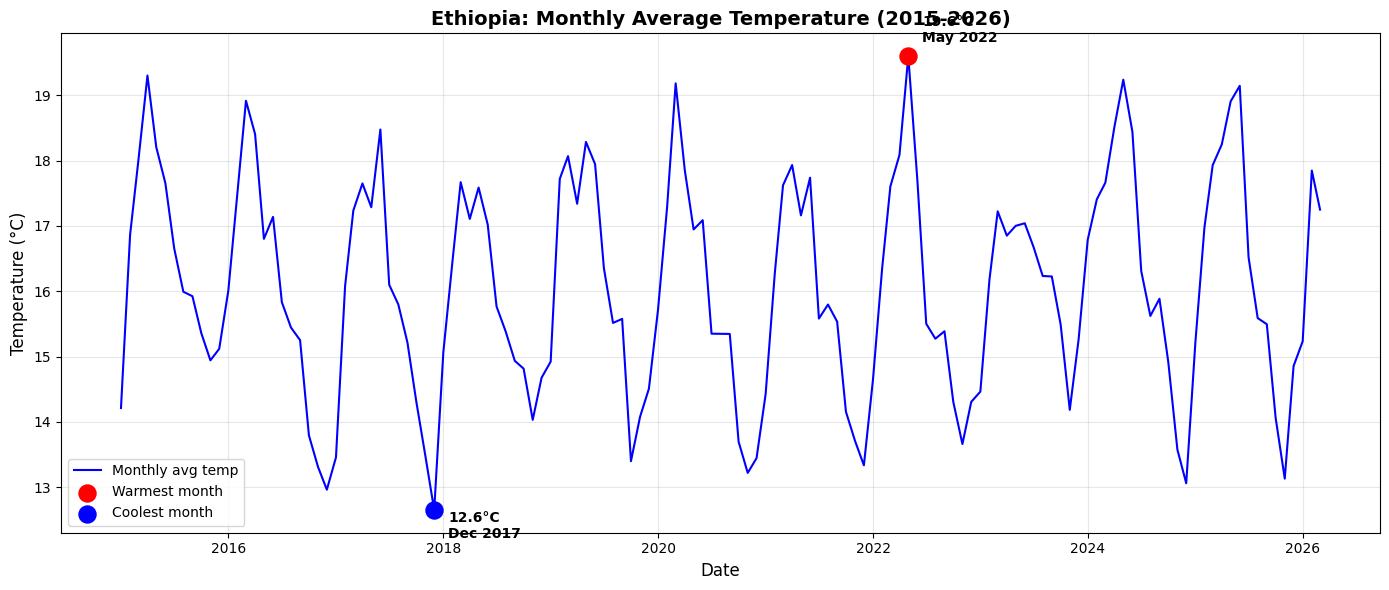


📊 Summary:
   Warmest month: May 2022 - 19.6°C
   Coolest month: December 2017 - 12.6°C
   Average temperature: 16.1°C


In [7]:
# Create monthly average temperature
monthly_temp = df_clean.groupby(['Year', 'Month'])['T2M'].mean().reset_index()
monthly_temp['Date'] = pd.to_datetime(monthly_temp['Year'].astype(str) + '-' + 
                                       monthly_temp['Month'].astype(str))

# Find warmest and coolest months
warmest = monthly_temp.loc[monthly_temp['T2M'].idxmax()]
coolest = monthly_temp.loc[monthly_temp['T2M'].idxmin()]

# Create plot
plt.figure(figsize=(14, 6))
plt.plot(monthly_temp['Date'], monthly_temp['T2M'], 'b-', linewidth=1.5, label='Monthly avg temp')

# Mark extremes
plt.scatter(warmest['Date'], warmest['T2M'], color='red', s=150, zorder=5, label='Warmest month')
plt.scatter(coolest['Date'], coolest['T2M'], color='blue', s=150, zorder=5, label='Coolest month')

# Add annotations
plt.annotate(f"{warmest['T2M']:.1f}°C\n{warmest['Date'].strftime('%b %Y')}", 
             xy=(warmest['Date'], warmest['T2M']), xytext=(10, 10),
             textcoords='offset points', fontsize=10, fontweight='bold')
plt.annotate(f"{coolest['T2M']:.1f}°C\n{coolest['Date'].strftime('%b %Y')}", 
             xy=(coolest['Date'], coolest['T2M']), xytext=(10, -20),
             textcoords='offset points', fontsize=10, fontweight='bold')

plt.title('Ethiopia: Monthly Average Temperature (2015-2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 Summary:")
print(f"   Warmest month: {warmest['Date'].strftime('%B %Y')} - {warmest['T2M']:.1f}°C")
print(f"   Coolest month: {coolest['Date'].strftime('%B %Y')} - {coolest['T2M']:.1f}°C")
print(f"   Average temperature: {monthly_temp['T2M'].mean():.1f}°C")

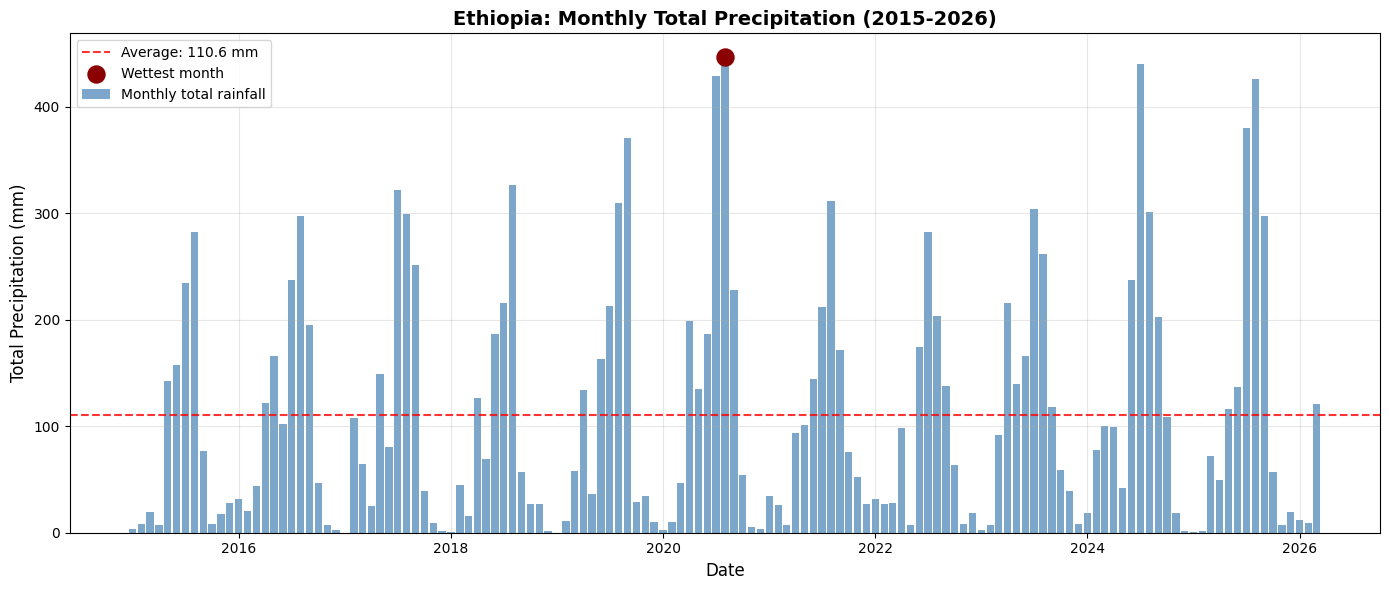


💧 Precipitation Summary:
   Wettest month: August 2020 - 446.6 mm
   Average monthly rainfall: 110.6 mm
   Total rainfall (2015-2026): 14927.6 mm


In [8]:
# Monthly total precipitation
monthly_precip = df_clean.groupby(['Year', 'Month'])['PRECTOTCORR'].sum().reset_index()
monthly_precip['Date'] = pd.to_datetime(monthly_precip['Year'].astype(str) + '-' + 
                                         monthly_precip['Month'].astype(str))

# Find wettest months
wettest = monthly_precip.loc[monthly_precip['PRECTOTCORR'].idxmax()]

# Create bar chart
plt.figure(figsize=(14, 6))
plt.bar(monthly_precip['Date'], monthly_precip['PRECTOTCORR'], 
        width=25, color='steelblue', alpha=0.7, label='Monthly total rainfall')

plt.axhline(y=monthly_precip['PRECTOTCORR'].mean(), color='red', linestyle='--', 
            alpha=0.8, label=f"Average: {monthly_precip['PRECTOTCORR'].mean():.1f} mm")

plt.scatter([wettest['Date']], [wettest['PRECTOTCORR']], 
            color='darkred', s=150, zorder=5, label='Wettest month')

plt.title('Ethiopia: Monthly Total Precipitation (2015-2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Precipitation (mm)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n💧 Precipitation Summary:")
print(f"   Wettest month: {wettest['Date'].strftime('%B %Y')} - {wettest['PRECTOTCORR']:.1f} mm")
print(f"   Average monthly rainfall: {monthly_precip['PRECTOTCORR'].mean():.1f} mm")
print(f"   Total rainfall (2015-2026): {monthly_precip['PRECTOTCORR'].sum():.1f} mm")

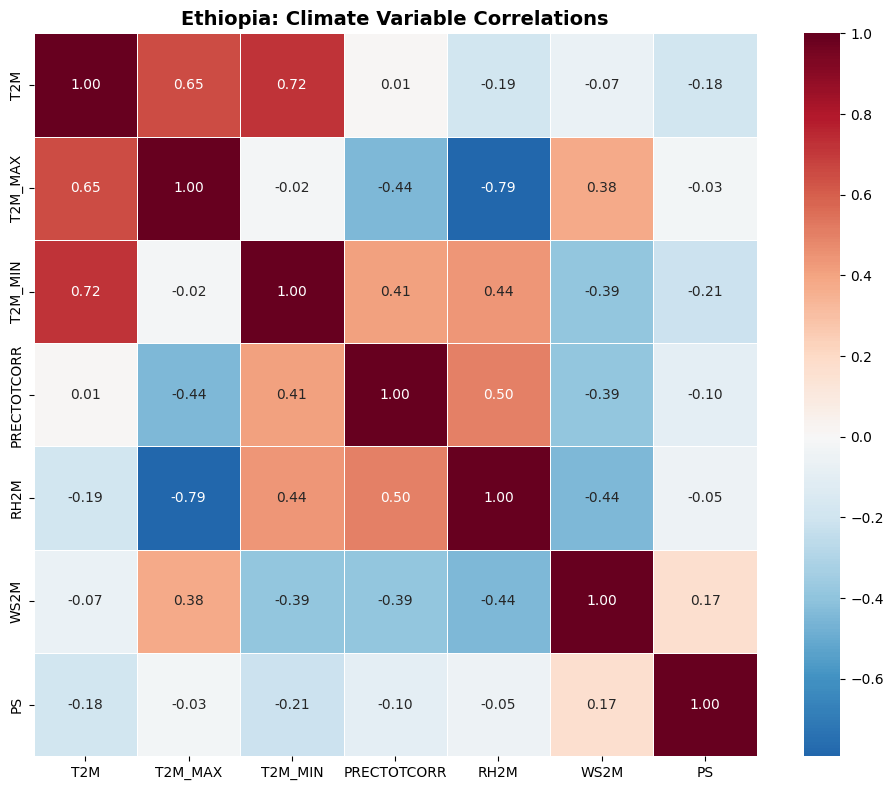


🔗 Strongest Positive Correlations:
   T2M_MIN ↔ T2M: 0.725
   T2M ↔ T2M_MIN: 0.725
   T2M_MAX ↔ T2M: 0.655

📉 Strongest Negative Correlations:
   T2M_MAX ↔ PRECTOTCORR: -0.445
   T2M_MAX ↔ RH2M: -0.792
   RH2M ↔ T2M_MAX: -0.792


In [9]:
# Select numeric columns for correlation
corr_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'PS']
corr_matrix = df_clean[corr_cols].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, 
            square=True, fmt='.2f', linewidths=0.5)
plt.title('Ethiopia: Climate Variable Correlations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Find strongest correlations (excluding self-correlation)
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 0.999]

print("\n🔗 Strongest Positive Correlations:")
for pair, value in corr_pairs.head(3).items():
    print(f"   {pair[0]} ↔ {pair[1]}: {value:.3f}")

print("\n📉 Strongest Negative Correlations:")
for pair, value in corr_pairs.tail(3).items():
    print(f"   {pair[0]} ↔ {pair[1]}: {value:.3f}")

Precipitation skewness: 3.17
(Positive skew = many dry days, few very wet days)


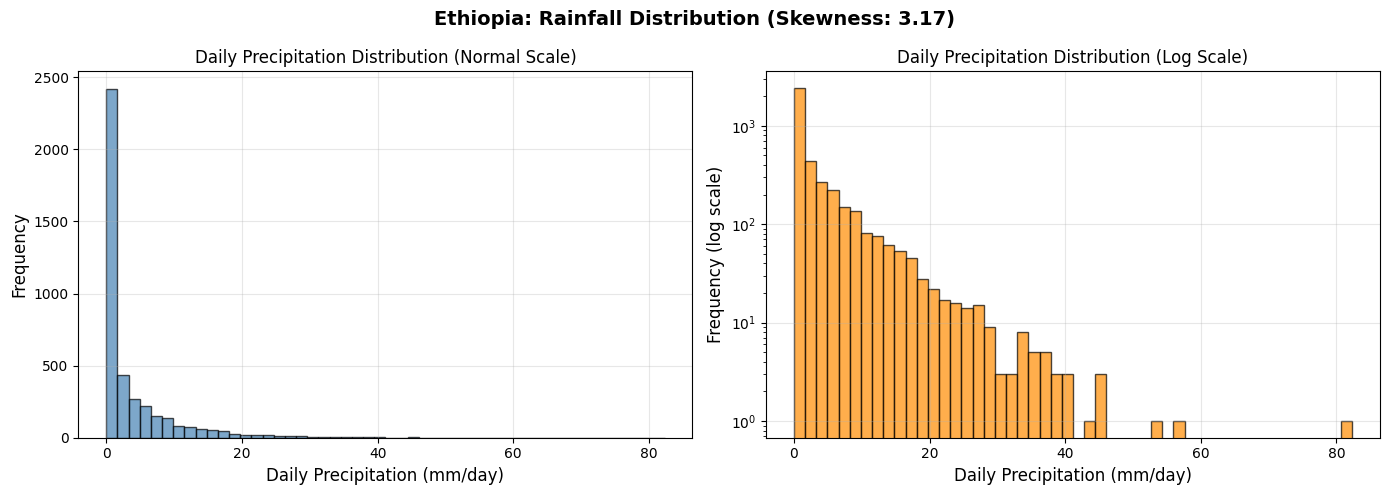


🌧️ Rainfall Statistics:
   Days with <1mm rain (dry days): 2161 (52.6%)
   Days with >10mm rain: 463
   Maximum daily rainfall: 82.3 mm


In [10]:
# Check skewness
skewness = df_clean['PRECTOTCORR'].skew()
print(f"Precipitation skewness: {skewness:.2f}")
print("(Positive skew = many dry days, few very wet days)")

# Create histogram with log scale
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Normal scale
ax1.hist(df_clean['PRECTOTCORR'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Daily Precipitation (mm/day)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Daily Precipitation Distribution (Normal Scale)', fontsize=12)
ax1.grid(True, alpha=0.3)

# Log scale
ax2.hist(df_clean['PRECTOTCORR'], bins=50, color='darkorange', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Daily Precipitation (mm/day)', fontsize=12)
ax2.set_ylabel('Frequency (log scale)', fontsize=12)
ax2.set_title('Daily Precipitation Distribution (Log Scale)', fontsize=12)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Ethiopia: Rainfall Distribution (Skewness: {skewness:.2f})', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate dry days
dry_days = (df_clean['PRECTOTCORR'] < 1).sum()
pct_dry = (dry_days / len(df_clean)) * 100
print(f"\n🌧️ Rainfall Statistics:")
print(f"   Days with <1mm rain (dry days): {dry_days} ({pct_dry:.1f}%)")
print(f"   Days with >10mm rain: {(df_clean['PRECTOTCORR'] > 10).sum()}")
print(f"   Maximum daily rainfall: {df_clean['PRECTOTCORR'].max():.1f} mm")

In [11]:
# Create comprehensive summary
numeric_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']
summary = df_clean[numeric_cols].agg(['mean', 'median', 'std', 'min', 'max']).round(2)

# Add coefficient of variation (std/mean * 100)
cv = (summary.loc['std'] / summary.loc['mean']) * 100
summary.loc['CV (%)'] = cv.round(1)

print("="*80)
print("ETHIOPIA CLIMATE SUMMARY (2015-2026)")
print("="*80)
print(summary.to_string())

# Key insights
print("\n" + "="*80)
print("KEY INSIGHTS FOR COP32")
print("="*80)
print(f"🌡️  Average temperature: {df_clean['T2M'].mean():.1f}°C")
print(f"☀️  Average maximum: {df_clean['T2M_MAX'].mean():.1f}°C")
print(f"❄️  Average minimum: {df_clean['T2M_MIN'].mean():.1f}°C")
print(f"💧  Average daily rainfall: {df_clean['PRECTOTCORR'].mean():.2f} mm")
print(f"🏜️  Dry days (%): {((df_clean['PRECTOTCORR'] < 1).sum() / len(df_clean)) * 100:.1f}%")

ETHIOPIA CLIMATE SUMMARY (2015-2026)
          T2M  T2M_MAX  T2M_MIN  PRECTOTCORR   RH2M   WS2M
mean    16.07    23.20    10.23         3.63  68.41   1.98
median  16.04    22.74    10.99         0.82  71.12   1.97
std      1.90     2.75     2.61         6.29  14.74   0.69
min     10.03    15.65     1.17         0.00  14.42   0.46
max     21.53    30.93    15.68        82.30  91.93   4.13
CV (%)  11.80    11.90    25.50       173.30  21.50  34.80

KEY INSIGHTS FOR COP32
🌡️  Average temperature: 16.1°C
☀️  Average maximum: 23.2°C
❄️  Average minimum: 10.2°C
💧  Average daily rainfall: 3.63 mm
🏜️  Dry days (%): 52.6%
